<a href="https://colab.research.google.com/github/siva651/Movie-RecommendationSystem/blob/main/MNIST_Handwritten_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
# STEP 0 — Setup

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
import gradio as gr
from PIL import Image

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {bool(tf.config.list_physical_devices('GPU'))}")

TensorFlow version: 2.20.0
GPU available: True


Train shape: (60000, 28, 28), Test shape: (10000, 28, 28)


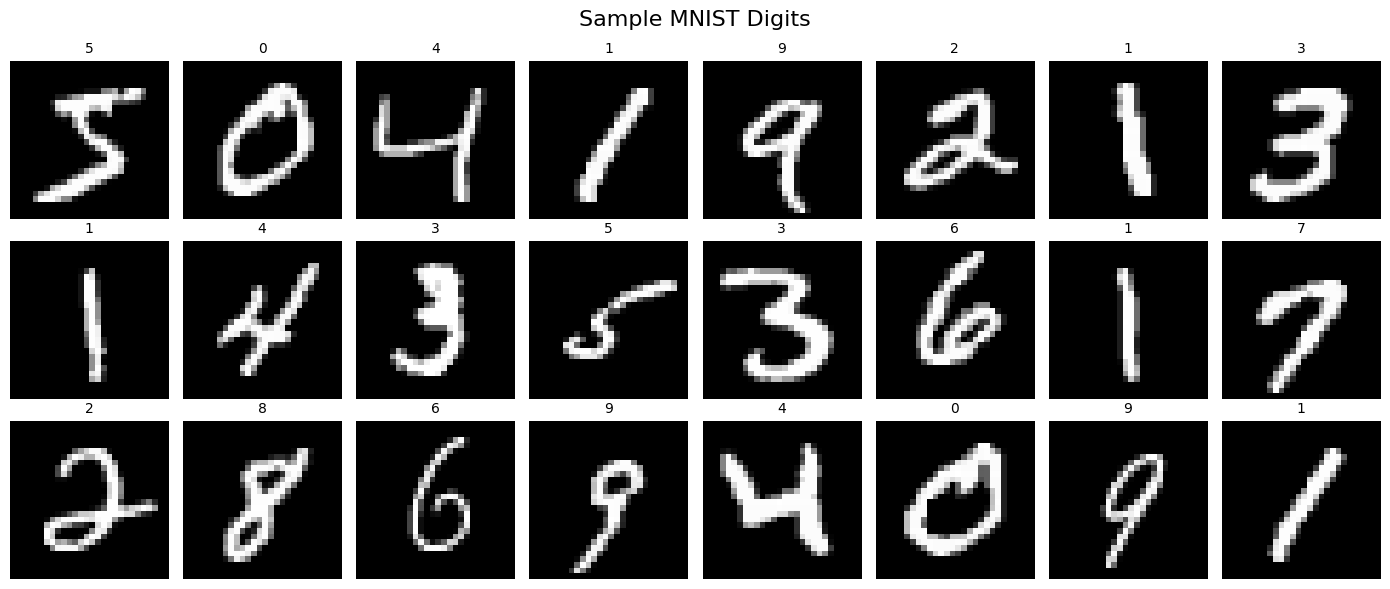

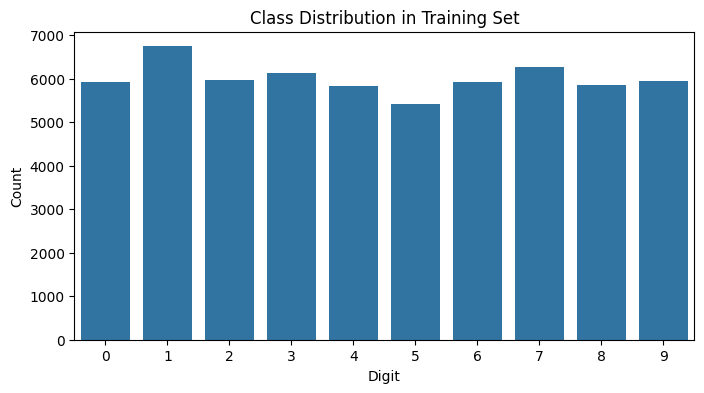

In [37]:
# ============================================================
# STEP 1 — Load & Explore the Data
# ============================================================
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Train shape: {x_train.shape}, Test shape: {x_test.shape}")

# --- Visual 1: Sample digits ---
fig, axes = plt.subplots(3, 8, figsize=(14, 6))
for ax, img, label in zip(axes.flat, x_train, y_train):
    ax.imshow(img, cmap='gray')
    ax.set_title(str(label), fontsize=10)
    ax.axis('off')
fig.suptitle("Sample MNIST Digits", fontsize=16)
plt.tight_layout()
plt.show()

# --- Visual 2: Class balance (good to show you checked for skew) ---
plt.figure(figsize=(8, 4))
sns.countplot(x=y_train)
plt.title("Class Distribution in Training Set")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

In [38]:
# ============================================================
# STEP 2 — Preprocess
# ============================================================
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test  = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

print("✅ Normalized to [0,1] and reshaped to (28, 28, 1)")

✅ Normalized to [0,1] and reshaped to (28, 28, 1)


In [39]:
# ============================================================
# STEP 3 — Build the CNN
# ============================================================
def build_model():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, 3, activation='relu'), layers.BatchNormalization(),
        layers.Conv2D(32, 3, activation='relu'), layers.BatchNormalization(),
        layers.MaxPooling2D(), layers.Dropout(0.25),

        layers.Conv2D(64, 3, activation='relu'), layers.BatchNormalization(),
        layers.Conv2D(64, 3, activation='relu'), layers.BatchNormalization(),
        layers.MaxPooling2D(), layers.Dropout(0.25),

        layers.Conv2D(128, 3, activation='relu'), layers.BatchNormalization(),
        layers.MaxPooling2D(), layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'), layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ], name="MNIST_CNN")

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_model()
model.summary()

# --- Visual: architecture diagram (great for a portfolio README) ---

Model: "MNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,746 (690.41 KB)

 Trainable params: 175,594 (685.91 KB)

 Non-trainable params: 1,152 (4.50 KB)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.8978 - loss: 0.3374 - val_accuracy: 0.5028 - val_loss: 1.6778 - learning_rate: 0.0010
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9757 - loss: 0.0809 - val_accuracy: 0.9901 - val_loss: 0.0320 - learning_rate: 0.0010
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9826 - loss: 0.0580 - val_accuracy: 0.9925 - val_loss: 0.0251 - learning_rate: 0.0010
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9854 - loss: 0.0475 - val_accuracy: 0.9918 - val_loss: 0.0241 - learning_rate: 0.0010
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9876 - loss: 0.0410 - val_accuracy: 0.9934 - val_loss: 0.0225 - learning_rate: 0.0010
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9897 - loss: 0.0357 - val_accuracy: 0.9938 - val_loss: 0.0201 - learning_rate: 0.0010
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9897 - loss: 0.033

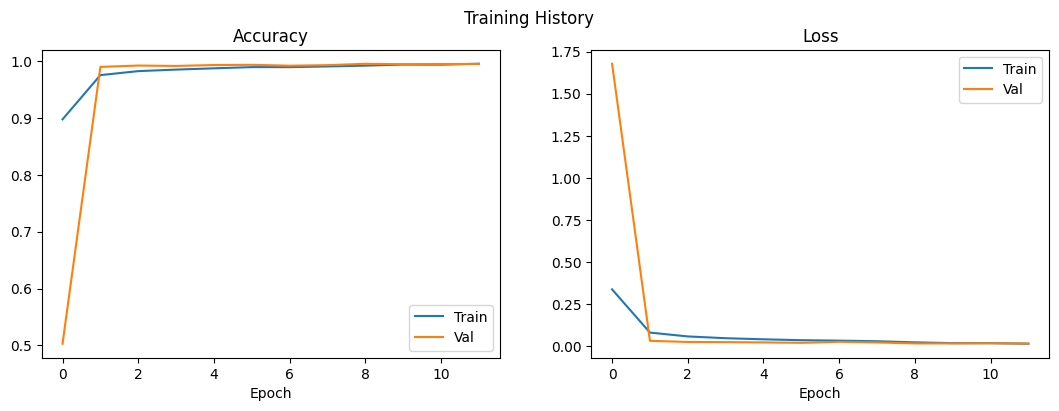

🚀 Final Test Accuracy: 99.56%


In [40]:
# ============================================================
# STEP 4 — Train (with callbacks — shows ML maturity)
# ============================================================
callbacks = [
    keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_accuracy'),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, monitor='val_loss')
]

history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    verbose=1
)

# --- Visual: training curves ---
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(history.history['accuracy'], label='Train')
ax[0].plot(history.history['val_accuracy'], label='Val')
ax[0].set_title('Accuracy'); ax[0].set_xlabel('Epoch'); ax[0].legend()

ax[1].plot(history.history['loss'], label='Train')
ax[1].plot(history.history['val_loss'], label='Val')
ax[1].set_title('Loss'); ax[1].set_xlabel('Epoch'); ax[1].legend()
plt.suptitle("Training History")
plt.show()

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"🚀 Final Test Accuracy: {test_acc*100:.2f}%")

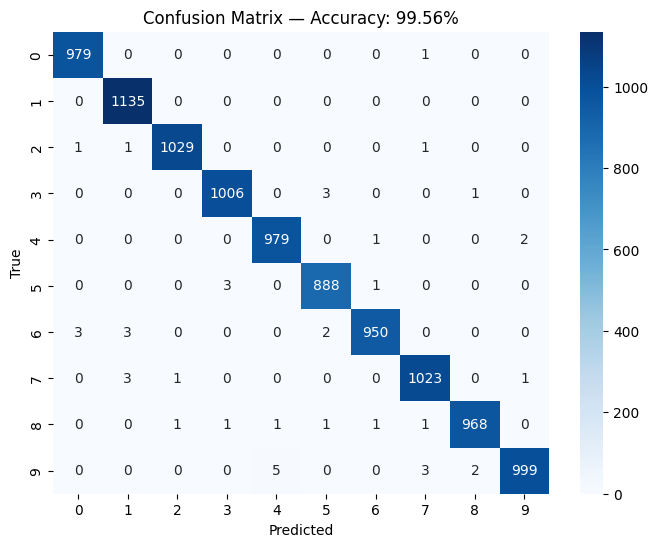

              precision    recall  f1-score   support

           0      0.996     0.999     0.997       980
           1      0.994     1.000     0.997      1135
           2      0.998     0.997     0.998      1032
           3      0.996     0.996     0.996      1010
           4      0.994     0.997     0.995       982
           5      0.993     0.996     0.994       892
           6      0.997     0.992     0.994       958
           7      0.994     0.995     0.995      1028
           8      0.997     0.994     0.995       974
           9      0.997     0.990     0.994      1009

    accuracy                          0.996     10000
   macro avg      0.996     0.996     0.996     10000
weighted avg      0.996     0.996     0.996     10000



/tmp/ipykernel_708/2819444834.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(range(10)), y=per_class_acc, palette='Blues_d')


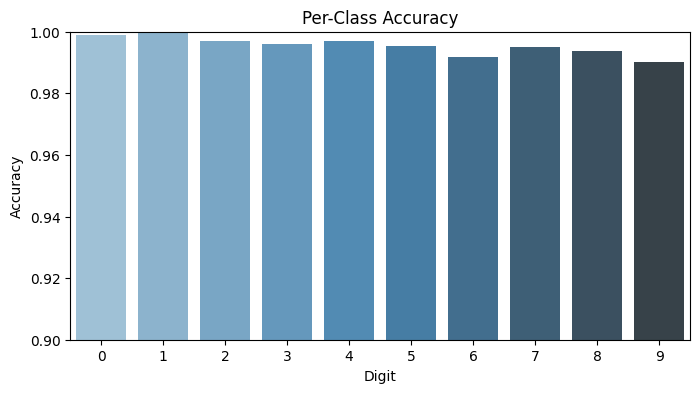

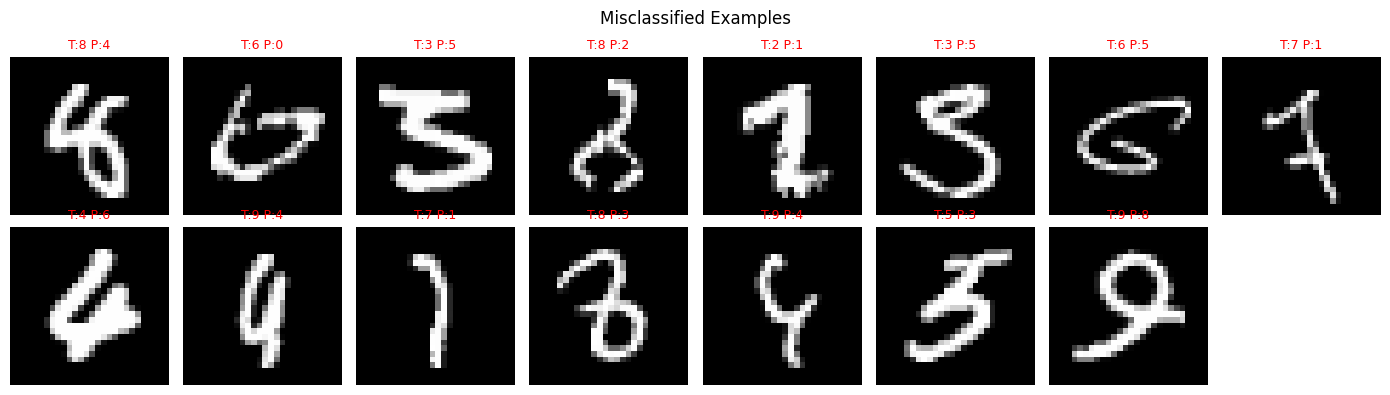

In [41]:
# ============================================================
# STEP 5 — Evaluate in Depth
# ============================================================
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# --- Visual: confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title(f'Confusion Matrix — Accuracy: {test_acc*100:.2f}%')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

print(classification_report(y_test, y_pred, digits=3))

# --- Visual: per-class accuracy bar chart ---
per_class_acc = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(8, 4))
sns.barplot(x=list(range(10)), y=per_class_acc, palette='Blues_d')
plt.title("Per-Class Accuracy")
plt.xlabel("Digit"); plt.ylabel("Accuracy"); plt.ylim(0.9, 1.0)
plt.show()

# --- Visual: misclassified examples (great talking point in interviews) ---
wrong_idx = np.where(y_pred != y_test)[0][:15]
plt.figure(figsize=(14, 4))
for i, idx in enumerate(wrong_idx):
    plt.subplot(2, 8, i+1)
    plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"T:{y_test[idx]} P:{y_pred[idx]}", color='red', fontsize=9)
    plt.axis('off')
plt.suptitle("Misclassified Examples")
plt.tight_layout()
plt.show()

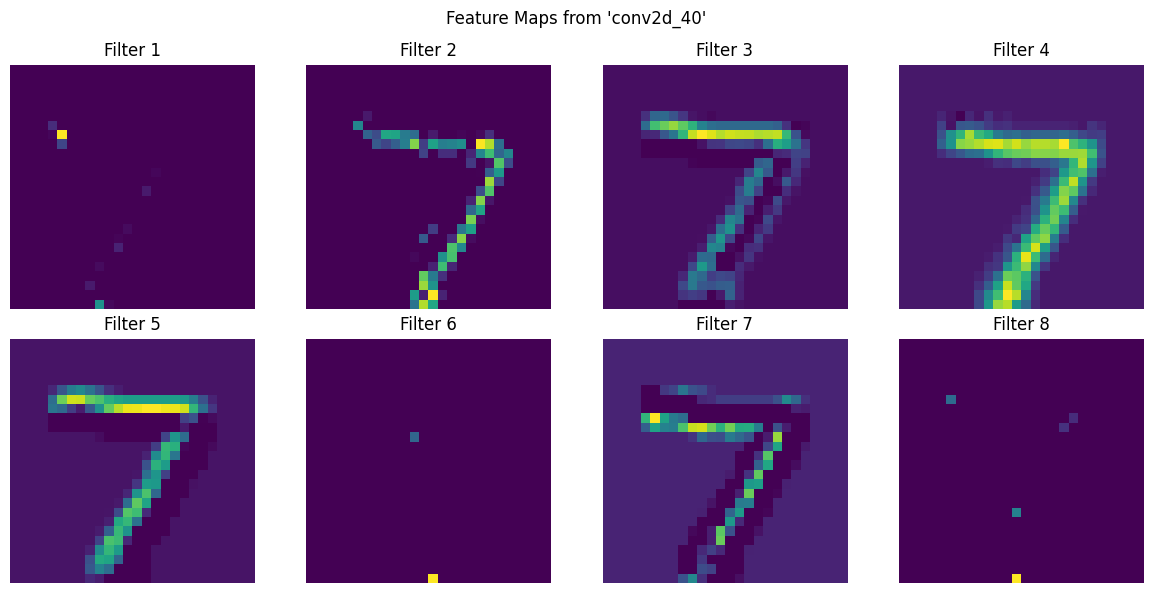

In [42]:
# ============================================================
# STEP 6 — Interpretability: What Does the CNN "See"?
# ============================================================
first_conv = next(l for l in model.layers if isinstance(l, layers.Conv2D))

feature_extractor = keras.Model(inputs=model.inputs, outputs=first_conv.output)
sample_img = x_test[0:1]
activations = feature_extractor.predict(sample_img, verbose=0)

plt.figure(figsize=(12, 6))
for i in range(min(8, activations.shape[-1])):
    plt.subplot(2, 4, i+1)
    plt.imshow(activations[0, :, :, i], cmap='viridis')
    plt.title(f'Filter {i+1}')
    plt.axis('off')
plt.suptitle(f"Feature Maps from '{first_conv.name}'")
plt.tight_layout()
plt.show()

In [43]:
# ============================================================
# STEP 7 — Save the Model
# ============================================================
model.save('mnist_cnn.keras')
print("✅ Model saved as mnist_cnn.keras")

✅ Model saved as mnist_cnn.keras


In [ ]:
# ============================================================
# STEP 8 — Interactive Demo (Gradio)
# Two input modes: draw a digit live, or upload an image.
# ============================================================
# ------------------------------------------------------------
# Load the trained model (don't rely on notebook memory)
# ------------------------------------------------------------
import os

if 'model' not in dir() or not isinstance(model, tf.keras.Model):
    print("⚠️ No trained model found in memory — loading from disk...")
    model = tf.keras.models.load_model('mnist_cnn.keras')
else:
    print("✅ Using model already in memory")

# Sanity check: confirm the model is actually trained, not random weights
sanity_probs = model.predict(x_test[0:1], verbose=0)[0]
print(f"Sanity check on a known test digit ({y_test[0]}): "
      f"predicted={np.argmax(sanity_probs)}, confidence={np.max(sanity_probs)*100:.1f}%")
if np.max(sanity_probs) < 0.5:
    print("🚨 WARNING: Low confidence on a known test image — model may be untrained!")


import gradio as gr
import numpy as np
from PIL import Image
from scipy import ndimage
import matplotlib.pyplot as plt

print(f"Gradio version: {gr.__version__}")

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------

def to_pil(img):
    """Normalize whatever Gradio hands us (dict, ndarray, or PIL) into a grayscale PIL Image,
    correctly flattening transparency onto a white background."""
    if img is None:
        return None

    # Sketchpad / ImageEditor in Gradio 5.x returns a dict
    if isinstance(img, dict):
        candidate = img.get("composite")
        if candidate is None:
            candidate = img.get("background")
        if candidate is None:
            layers = img.get("layers")
            candidate = layers[0] if layers else None
        img = candidate

    if img is None:
        return None

    if isinstance(img, np.ndarray):
        if img.size == 0:
            return None
        img = Image.fromarray(img.astype('uint8'))

    # Critical fix: flatten transparency onto white BEFORE dropping alpha,
    # otherwise transparent pixels can turn black once alpha is discarded.
    if img.mode in ("RGBA", "LA"):
        background = Image.new("RGB", img.size, (255, 255, 255))
        alpha = img.split()[-1]
        background.paste(img.convert("RGB"), mask=alpha)
        img = background

    return img.convert("L")


def center_on_canvas(arr, size=28, digit_size=20):
    """Crop to the digit's bounding box, resize, and center — mimics MNIST's own preprocessing."""
    coords = np.argwhere(arr > 0.05)
    if coords.size == 0:
        return np.zeros((size, size), dtype='float32')

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    cropped = arr[y0:y1, x0:x1]

    h, w = cropped.shape
    scale = digit_size / max(h, w)
    new_h, new_w = max(1, int(h * scale)), max(1, int(w * scale))
    cropped_img = Image.fromarray((cropped * 255).astype('uint8')).resize(
        (new_w, new_h), Image.Resampling.LANCZOS
    )
    resized = np.array(cropped_img).astype('float32') / 255.0

    canvas = np.zeros((size, size), dtype='float32')
    top = (size - new_h) // 2
    left = (size - new_w) // 2
    canvas[top:top + new_h, left:left + new_w] = resized

    cy, cx = ndimage.center_of_mass(canvas)
    if not (np.isnan(cy) or np.isnan(cx)):
        shift_y, shift_x = int(size / 2 - cy), int(size / 2 - cx)
        canvas = ndimage.shift(canvas, (shift_y, shift_x), cval=0)
    return canvas


def preprocess(img) -> np.ndarray:
    pil_img = to_pil(img)
    if pil_img is None:
        return None

    arr = np.array(pil_img).astype('float32') / 255.0

    # Auto-invert: MNIST wants a light digit on a dark background.
    if arr.mean() > 0.5:
        arr = 1.0 - arr

    arr = center_on_canvas(arr)
    return arr.reshape(1, 28, 28, 1)


# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

def predict(img):
    if img is None:
        print("⚠️ predict() received None")
        return None, None

    x = preprocess(img)
    if x is None:
        print("⚠️ preprocess() returned None — check to_pil() logic")
        return None, None

    probs = model.predict(x, verbose=0)[0]
    pred, conf = int(np.argmax(probs)), float(np.max(probs)) * 100

    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(range(10), probs, color=['#4C72B0' if i != pred else '#DD8452' for i in range(10)])
    ax.set_xticks(range(10))
    ax.set_ylim(0, 1)
    ax.set_title(f"Prediction: {pred}  ({conf:.1f}% confident)")
    plt.tight_layout()

    return fig, x.reshape(28, 28)


# ------------------------------------------------------------
# UI
# ------------------------------------------------------------

with gr.Blocks(title="Handwritten Digit Classifier") as demo:
    gr.Markdown("# 🔢 Handwritten Digit Classifier\nCNN trained on MNIST — draw a digit or upload an image.")

    with gr.Tab("✏️ Draw"):
        if hasattr(gr, "Sketchpad"):
            sketch = gr.Sketchpad(type="pil", label="Draw a digit (0-9)")
        else:
            sketch = gr.Image(source="canvas", tool="sketch", type="pil", label="Draw a digit (0-9)")
        btn1 = gr.Button("Predict", variant="primary")

    with gr.Tab("📁 Upload"):
        upload = gr.Image(type="pil", label="Upload an image", sources=["upload", "clipboard"])
        btn2 = gr.Button("Predict", variant="primary")

    with gr.Row():
        out_chart = gr.Plot(label="Prediction Confidence")
        out_processed = gr.Image(label="What the model sees (28x28)")

    btn1.click(predict, inputs=sketch, outputs=[out_chart, out_processed])
    btn2.click(predict, inputs=upload, outputs=[out_chart, out_processed])
    upload.change(predict, inputs=upload, outputs=[out_chart, out_processed])

demo.launch(share=True, debug=True)

✅ Using model already in memory
Sanity check on a known test digit (7): predicted=7, confidence=100.0%
Gradio version: 6.20.0
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d4cc7f0aea1681cc28.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


⚠️ predict() received None
